# All-in-One Machine Learning Models Notebook
This single notebook implements the most commonly used **Machine Learning models** using `scikit-learn`.
Every code line has an inline comment explaining what it does.

**Models covered:**
- Linear Regression
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest
- Gradient Boosting
- Naive Bayes
- K-Means Clustering (unsupervised)
- Principal Component Analysis - PCA (dimensionality reduction)


In [1]:
# Import numpy for numerical operations
import numpy as np
# Import pandas for handling tabular data
import pandas as pd
# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import function to split data into train and test sets
from sklearn.model_selection import train_test_split
# Import function to scale/standardize features
from sklearn.preprocessing import StandardScaler

# Import built-in datasets from sklearn (these load from local package data, no internet needed)
from sklearn.datasets import load_iris, load_diabetes

# Import metrics used to evaluate classification models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Import metrics used to evaluate regression models
from sklearn.metrics import mean_squared_error, r2_score

# Import all the ML model classes we will use below
from sklearn.linear_model import LinearRegression, LogisticRegression   # linear models
from sklearn.neighbors import KNeighborsClassifier                       # KNN
from sklearn.svm import SVC                                              # Support Vector Machine
from sklearn.tree import DecisionTreeClassifier                          # Decision Tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # ensemble models
from sklearn.naive_bayes import GaussianNB                               # Naive Bayes
from sklearn.cluster import KMeans                                       # K-Means clustering
from sklearn.decomposition import PCA                                    # PCA for dimensionality reduction

# Set a random seed so results are reproducible every time we run the notebook
RANDOM_STATE = 42


## 1. Load and Prepare Data
We use the **Iris dataset** for all classification models and the **Diabetes dataset** for the regression model.

In [2]:
# Load the iris dataset (150 flower samples, 4 features, 3 classes)
iris = load_iris()
# Extract the feature matrix (X) from the iris dataset
X_clf = iris.data
# Extract the target labels (y) from the iris dataset
y_clf = iris.target

# Split iris data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE  # keep 20% for testing, fixed seed
)

# Create a StandardScaler object to standardize features (mean=0, std=1)
scaler = StandardScaler()
# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
# Transform the test data using the SAME scaler (no re-fitting, to avoid data leakage)
X_test_scaled = scaler.transform(X_test)

# Print the shapes to confirm the split worked correctly
print("Classification -> Train shape:", X_train.shape, "Test shape:", X_test.shape)


Classification -> Train shape: (120, 4) Test shape: (30, 4)


In [3]:
# Load the diabetes dataset for regression (features -> disease progression score)
diabetes = load_diabetes()
# Extract feature matrix for regression task
X_reg = diabetes.data
# Extract continuous target variable (disease progression measure) for regression task
y_reg = diabetes.target

# Split regression data into training and testing sets
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE  # 80/20 split, fixed seed
)

# Standardize regression features the same way as classification features
reg_scaler = StandardScaler()          # create a separate scaler for regression data
Xr_train_scaled = reg_scaler.fit_transform(Xr_train)   # fit + transform training data
Xr_test_scaled = reg_scaler.transform(Xr_test)          # transform test data only

# Print shapes to confirm the regression split worked
print("Regression -> Train shape:", Xr_train.shape, "Test shape:", Xr_test.shape)


Regression -> Train shape: (353, 10) Test shape: (89, 10)


## 2. Linear Regression
Predicts a continuous value (California housing prices).

In [4]:
# Create a Linear Regression model object
lin_reg = LinearRegression()
# Train (fit) the model on the scaled regression training data
lin_reg.fit(Xr_train_scaled, yr_train)
# Use the trained model to predict house prices on the test set
yr_pred = lin_reg.predict(Xr_test_scaled)

# Calculate Mean Squared Error between actual and predicted values
mse = mean_squared_error(yr_test, yr_pred)
# Calculate R-squared score (how well the model explains variance)
r2 = r2_score(yr_test, yr_pred)

# Print evaluation metrics for Linear Regression
print("Linear Regression -> MSE:", mse, "| R2 Score:", r2)


Linear Regression -> MSE: 2900.193628493483 | R2 Score: 0.45260276297191915


## 3. Logistic Regression
A classification model despite the name 'regression'.

In [5]:
# Create a Logistic Regression model with a max iteration limit to ensure convergence
log_reg = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
# Train the model on the scaled classification training data
log_reg.fit(X_train_scaled, y_train)
# Predict class labels on the test data
y_pred_log = log_reg.predict(X_test_scaled)

# Print the accuracy of Logistic Regression on the test set
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
# Print detailed precision/recall/f1-score report per class
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 4. K-Nearest Neighbors (KNN)

In [6]:
# Create a KNN classifier that looks at the 5 nearest neighbors
knn = KNeighborsClassifier(n_neighbors=5)
# Train the KNN model (KNN just stores the training data, no real 'training' happens)
knn.fit(X_train_scaled, y_train)
# Predict labels for the test data based on nearest neighbors
y_pred_knn = knn.predict(X_test_scaled)

# Print the accuracy achieved by KNN
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 1.0


## 5. Support Vector Machine (SVM)

In [7]:
# Create an SVM classifier with an RBF (non-linear) kernel
svm_model = SVC(kernel='rbf', random_state=RANDOM_STATE)
# Train the SVM model on the scaled training data
svm_model.fit(X_train_scaled, y_train)
# Predict labels on the test data using the trained SVM
y_pred_svm = svm_model.predict(X_test_scaled)

# Print SVM accuracy on the test set
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 1.0


## 6. Decision Tree

In [8]:
# Create a Decision Tree classifier with a fixed random state for reproducibility
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
# Train the decision tree on the (unscaled) training data - trees don't need scaling
dt_model.fit(X_train, y_train)
# Predict labels on the test set
y_pred_dt = dt_model.predict(X_test)

# Print Decision Tree accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 1.0


## 7. Random Forest (Ensemble of Decision Trees)

In [9]:
# Create a Random Forest with 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
# Train the random forest on the training data
rf_model.fit(X_train, y_train)
# Predict labels on the test set
y_pred_rf = rf_model.predict(X_test)

# Print Random Forest accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
# Print which features were most important for the model's decisions
print("Feature Importances:", rf_model.feature_importances_)


Random Forest Accuracy: 1.0
Feature Importances: [0.10809762 0.03038681 0.43999397 0.42152159]


## 8. Gradient Boosting

In [10]:
# Create a Gradient Boosting classifier with 100 boosting stages
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
# Train the gradient boosting model on the training data
gb_model.fit(X_train, y_train)
# Predict labels on the test data
y_pred_gb = gb_model.predict(X_test)

# Print Gradient Boosting accuracy
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))


Gradient Boosting Accuracy: 1.0


## 9. Naive Bayes

In [11]:
# Create a Gaussian Naive Bayes classifier (assumes features follow normal distribution)
nb_model = GaussianNB()
# Train the Naive Bayes model on the training data
nb_model.fit(X_train, y_train)
# Predict labels on the test set
y_pred_nb = nb_model.predict(X_test)

# Print Naive Bayes accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))


Naive Bayes Accuracy: 1.0


## 10. K-Means Clustering (Unsupervised Learning)

In [12]:
# Create a K-Means model to find 3 clusters (we know iris has 3 species)
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
# Fit K-Means on the full scaled classification feature set (no labels used - unsupervised)
kmeans.fit(scaler.fit_transform(X_clf))
# Get the cluster label assigned to each data point
cluster_labels = kmeans.labels_

# Print the resulting cluster assignments for the first 10 samples
print("First 10 cluster assignments:", cluster_labels[:10])
# Print the coordinates of the cluster centers
print("Cluster Centers:\n", kmeans.cluster_centers_)


First 10 cluster assignments: [1 1 1 1 1 1 1 1 1 1]
Cluster Centers:
 [[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


## 11. Principal Component Analysis (PCA) - Dimensionality Reduction

Explained Variance Ratio: [0.72962445 0.22850762]


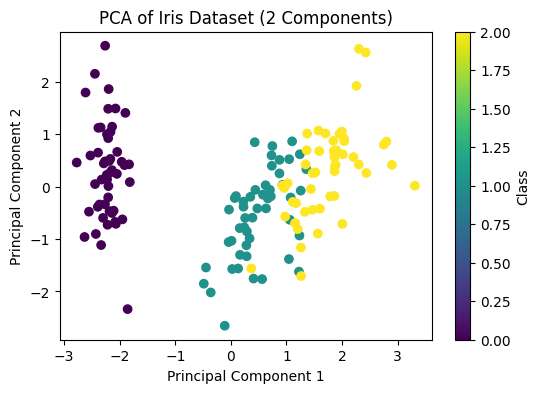

In [13]:
# Create a PCA object to reduce the 4 iris features down to 2 principal components
pca = PCA(n_components=2)
# Fit PCA and transform the scaled iris features into 2D
X_pca = pca.fit_transform(scaler.fit_transform(X_clf))

# Print how much variance each of the 2 components explains
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Create a scatter plot of the 2 principal components, colored by true class label
plt.figure(figsize=(6, 4))                                  # set figure size
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_clf, cmap='viridis')  # plot PC1 vs PC2 colored by class
plt.xlabel("Principal Component 1")                          # label x-axis
plt.ylabel("Principal Component 2")                          # label y-axis
plt.title("PCA of Iris Dataset (2 Components)")              # add a title
plt.colorbar(label="Class")                                   # add a color legend
plt.show()                                                    # display the plot


## 12. Model Comparison Summary
Compare accuracy of every classification model trained above.

In [14]:
# Build a dictionary mapping each model's name to its test accuracy
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),  # accuracy for logistic regression
    "KNN": accuracy_score(y_test, y_pred_knn),                    # accuracy for KNN
    "SVM": accuracy_score(y_test, y_pred_svm),                    # accuracy for SVM
    "Decision Tree": accuracy_score(y_test, y_pred_dt),           # accuracy for decision tree
    "Random Forest": accuracy_score(y_test, y_pred_rf),           # accuracy for random forest
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),       # accuracy for gradient boosting
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),             # accuracy for naive bayes
}

# Convert the results dictionary into a pandas DataFrame for a clean table view
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
# Sort the models by accuracy in descending order
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# Display the final comparison table
print(results_df)


                 Model  Accuracy
0  Logistic Regression       1.0
1                  KNN       1.0
2                  SVM       1.0
3        Decision Tree       1.0
4        Random Forest       1.0
5    Gradient Boosting       1.0
6          Naive Bayes       1.0
